# NFL Margin of Victory Prediction
This notebook includes all of our code for our analysis and figures featured in the report. The initial cells up until compile the data that is stored in matchups.csv.

Reimplementing Warner (2010) on modern data (2015–2024) to evaluate whether Vegas has gotten sharper.

**Setup:** `pip install pandas numpy scikit-learn`

**Data window:**
- Train: 2015–2022
- Test: 2023–2024 (mirrors the paper's 8-year train / 2-year test split)

In [2]:
import pandas as pd
import numpy as np

TRAIN_SEASONS = list(range(2015, 2023))  # 2015–2022
TEST_SEASONS  = list(range(2023, 2025))  # 2023–2024
ALL_SEASONS   = TRAIN_SEASONS + TEST_SEASONS

BASE_STATS = [
    "points_scored", "points_allowed",
    "total_yards", "total_yards_allowed",
    "rush_yards", "rush_yards_allowed",
    "pass_yards", "pass_yards_allowed",
    "turnovers_taken", "turnovers_lost",
]

## 1. Game Schedules, Scores, and Spreads

In [3]:
games = pd.read_csv(
    "https://raw.githubusercontent.com/nflverse/nfldata/master/data/games.csv",
    low_memory=False
)

# Regular season only, completed games, within our window
games = games[
    (games["game_type"] == "REG") &
    (games["result"].notna()) &
    (games["season"].isin(ALL_SEASONS))
].copy()

# result = home_score - away_score
# spread_line = Vegas spread (negative = home favored)
print(f"Games loaded: {len(games)} ({games['season'].min()}–{games['season'].max()})")
games[["season", "week", "home_team", "away_team", "home_score", "away_score", "result", "spread_line"]].head()

Games loaded: 2623 (2015–2024)


,season,week,home_team,away_team,home_score,away_score,result,spread_line
4248,2015,1,NE,PIT,28,21,7,7.5
4249,2015,1,BUF,IND,27,14,13,-1.0
4250,2015,1,CHI,GB,23,31,-8,-5.5
4251,2015,1,HOU,KC,20,27,-7,-1.0
4252,2015,1,JAX,CAR,9,20,-11,-3.0


## 2. Play-by-Play Data
Each season is ~50MB — expect a few minutes to load all 10 seasons.

In [4]:
pbp_frames = []
for yr in ALL_SEASONS:
    url = f"https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_{yr}.csv.gz"
    try:
        df = pd.read_csv(url, compression="gzip", low_memory=False)
        pbp_frames.append(df)
        print(f"  {yr}: {len(df):,} plays")
    except Exception as e:
        print(f"  {yr}: FAILED — {e}")

pbp = pd.concat(pbp_frames, ignore_index=True)
print(f"\nTotal plays: {len(pbp):,}")

  2015: 48,122 plays
  2016: 47,651 plays
  2017: 47,245 plays
  2018: 47,109 plays
  2019: 47,260 plays
  2020: 47,705 plays
  2021: 49,922 plays
  2022: 49,434 plays
  2023: 49,665 plays
  2024: 49,492 plays

Total plays: 483,605


## 3. Aggregate Play-by-Play Into Per-Game Team Stats
Warner's 10 base stats: points scored/allowed, total/rush/pass yards (offense + defense), turnovers taken/lost.

In [5]:
plays = pbp[pbp["play_type"].isin(["run", "pass", "qb_kneel", "qb_spike"])].copy()

for col in ["yards_gained", "rushing_yards", "passing_yards", "interception", "fumble_lost"]:
    plays[col] = plays[col].fillna(0)

# Offensive stats (per possession team)
off_stats = plays.groupby(["season", "week", "posteam", "game_id"]).agg(
    total_yards=("yards_gained", "sum"),
    rush_yards=("rushing_yards", "sum"),
    pass_yards=("passing_yards", "sum"),
    interceptions_thrown=("interception", "sum"),
    fumbles_lost=("fumble_lost", "sum"),
).reset_index()
off_stats["turnovers_lost"] = off_stats["interceptions_thrown"] + off_stats["fumbles_lost"]

# Defensive stats (yards/turnovers the opponent racked up against you)
def_stats = plays.groupby(["season", "week", "defteam", "game_id"]).agg(
    total_yards_allowed=("yards_gained", "sum"),
    rush_yards_allowed=("rushing_yards", "sum"),
    pass_yards_allowed=("passing_yards", "sum"),
    turnovers_taken_int=("interception", "sum"),
    turnovers_taken_fum=("fumble_lost", "sum"),
).reset_index()
def_stats["turnovers_taken"] = def_stats["turnovers_taken_int"] + def_stats["turnovers_taken_fum"]
def_stats = def_stats.rename(columns={"defteam": "posteam"})
def_stats = def_stats[["season", "week", "posteam", "game_id",
                        "total_yards_allowed", "rush_yards_allowed",
                        "pass_yards_allowed", "turnovers_taken"]]

team_stats = off_stats.merge(def_stats, on=["season", "week", "posteam", "game_id"], how="inner")

# Add points from game-level data
team_stats = team_stats.merge(
    games[["game_id", "home_team", "away_team", "home_score", "away_score"]],
    on="game_id", how="left"
)
team_stats["points_scored"] = np.where(
    team_stats["posteam"] == team_stats["home_team"],
    team_stats["home_score"], team_stats["away_score"]
)
team_stats["points_allowed"] = np.where(
    team_stats["posteam"] == team_stats["home_team"],
    team_stats["away_score"], team_stats["home_score"]
)

team_stats = team_stats[["season", "week", "posteam", "game_id",
                          "home_team", "away_team"] + BASE_STATS]

print(f"Team-game rows: {len(team_stats):,}")
team_stats.head()

Team-game rows: 5,486


,season,week,posteam,game_id,home_team,away_team,points_scored,points_allowed,total_yards,total_yards_allowed,rush_yards,rush_yards_allowed,pass_yards,pass_yards_allowed,turnovers_taken,turnovers_lost
0,2015,1,ARI,2015_01_NO_ARI,ARI,NO,31.0,19.0,427.0,408.0,120.0,54.0,307.0,355.0,1.0,1.0
1,2015,1,ATL,2015_01_PHI_ATL,ATL,PHI,26.0,24.0,395.0,399.0,105.0,63.0,298.0,336.0,2.0,2.0
2,2015,1,BAL,2015_01_BAL_DEN,DEN,BAL,13.0,19.0,173.0,219.0,73.0,69.0,117.0,175.0,1.0,2.0
3,2015,1,BUF,2015_01_IND_BUF,BUF,IND,27.0,14.0,342.0,306.0,147.0,64.0,195.0,243.0,2.0,0.0
4,2015,1,CAR,2015_01_CAR_JAX,JAX,CAR,20.0,9.0,263.0,265.0,105.0,96.0,175.0,183.0,3.0,1.0


## 4. Season-to-Date Averages and 4-Game Streaks
All features are computed from *prior* games only (shifted by 1) to avoid leakage.

In [6]:
team_stats = team_stats.sort_values(["season", "posteam", "week"]).reset_index(drop=True)

# Season-to-date expanding mean
for col in BASE_STATS:
    team_stats[f"{col}_avg"] = (
        team_stats.groupby(["season", "posteam"])[col]
        .transform(lambda x: x.expanding().mean().shift(1))
    )

# 4-game rolling mean (streak)
for col in BASE_STATS:
    team_stats[f"{col}_streak"] = (
        team_stats.groupby(["season", "posteam"])[col]
        .transform(lambda x: x.rolling(4, min_periods=4).mean().shift(1))
    )

# Win percentage (season-to-date and 4-game)
team_stats["win"] = (team_stats["points_scored"] > team_stats["points_allowed"]).astype(int)
team_stats["win_pct"] = (
    team_stats.groupby(["season", "posteam"])["win"]
    .transform(lambda x: x.expanding().mean().shift(1))
)
team_stats["win_pct_streak"] = (
    team_stats.groupby(["season", "posteam"])["win"]
    .transform(lambda x: x.rolling(4, min_periods=4).mean().shift(1))
)

print(f"Rows with valid 4-game streak: {team_stats['points_scored_streak'].notna().sum():,}")

Rows with valid 4-game streak: 4,096


## 5. Computed Strength Rankings
Eigenvalue-based team strength from Warner (2010) Section 2.2.1. Computed using only prior games in the same season (no leakage).

- `S_ij` = total points team i scored against team j so far
- `a_ij = h((S_ij + 1) / (S_ij + S_ji + 2))` where `h(x) = 0.5 + 0.5·sgn(x−0.5)·√|2x−1|`
- Dominant eigenvector of A (via power iteration) = team strength vector

In [7]:
def h_func(x):
    """Keener smoothing: rewards winning, diminishes blowouts."""
    return 0.5 + 0.5 * np.sign(x - 0.5) * np.sqrt(np.abs(2 * x - 1))

def compute_strength(games_df):
    """
    Compute Keener strength ratings for all teams in games_df.
    Returns dict of team -> strength (dominant eigenvector of A).
    """
    teams = sorted(set(games_df["home_team"]) | set(games_df["away_team"]))
    n = len(teams)
    idx = {t: i for i, t in enumerate(teams)}

    # S[i][j] = total points team i scored against team j
    S = np.zeros((n, n))
    for _, row in games_df.iterrows():
        i, j = idx[row["home_team"]], idx[row["away_team"]]
        S[i][j] += row["home_score"]
        S[j][i] += row["away_score"]

    # Build A matrix
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            total = S[i][j] + S[j][i]
            if total > 0:
                A[i][j] = h_func((S[i][j] + 1) / (total + 2))

    # Power iteration for dominant eigenvector
    r = np.ones(n) / n
    for _ in range(200):
        r_new = A @ r
        norm = r_new.sum()
        if norm == 0:
            break
        r_new /= norm
        if np.allclose(r, r_new, atol=1e-10):
            break
        r = r_new

    return dict(zip(teams, r))

# Compute strength per team per week using only prior games
strength_records = []
for season in ALL_SEASONS:
    season_g = games[games["season"] == season].dropna(subset=["home_score", "away_score"])
    for week in sorted(season_g["week"].unique()):
        prior = season_g[season_g["week"] < week]
        if len(prior) < 4:
            continue
        for team, strength in compute_strength(prior).items():
            strength_records.append({
                "season": season, "week": week,
                "posteam": team, "computed_strength": strength
            })

computed_strength_df = pd.DataFrame(strength_records)
print(f"Keener strength records: {len(computed_strength_df):,}")

# Sanity check: top 5 teams in week 10 of 2022
sample = computed_strength_df[(computed_strength_df["season"] == 2022) & (computed_strength_df["week"] == 10)]
print("\nTop 5 teams by Keener strength, 2022 week 10:")
print(sample.sort_values("computed_strength", ascending=False).head().to_string(index=False))

Keener strength records: 5,246

Top 5 teams by Keener strength, 2022 week 10:
 season  week posteam  computed_strength
   2022    10     BAL           0.051263
   2022    10     CIN           0.046033
   2022    10     MIA           0.043219
   2022    10     NYJ           0.042798
   2022    10     BUF           0.042763


## 6. Build Matchup-Level Dataset
Each row is one game: home team features (H_) and away team features (A_) paired with the result and spread.

In [8]:
FEATURE_COLS = (
    [f"{c}_avg"    for c in BASE_STATS] +
    [f"{c}_streak" for c in BASE_STATS] +
    ["win_pct", "win_pct_streak"]
)

home = team_stats[team_stats["posteam"] == team_stats["home_team"]].copy()
away = team_stats[team_stats["posteam"] == team_stats["away_team"]].copy()

home = home.rename(columns={c: f"H_{c}" for c in FEATURE_COLS})
away = away.rename(columns={c: f"A_{c}" for c in FEATURE_COLS})

matchups = home[["game_id", "season", "week"] + [f"H_{c}" for c in FEATURE_COLS]].merge(
    away[["game_id"] + [f"A_{c}" for c in FEATURE_COLS]],
    on="game_id", how="inner"
)
matchups = matchups.merge(
    games[["game_id", "result", "spread_line", "home_team", "away_team"]],
    on="game_id", how="left"
)

# Merge Keener strength for home and away teams
matchups = matchups.merge(
    computed_strength_df.rename(columns={"posteam": "home_team", "computed_strength": "H_computed_strength"}),
    on=["season", "week", "home_team"], how="left"
)
matchups = matchups.merge(
    computed_strength_df.rename(columns={"posteam": "away_team", "computed_strength": "A_computed_strength"}),
    on=["season", "week", "away_team"], how="left"
)

# Drop games where either team lacks enough history (first 4 weeks of each season)
all_feat_cols = [f"H_{c}" for c in FEATURE_COLS] + [f"A_{c}" for c in FEATURE_COLS]
matchups = matchups.dropna(subset=all_feat_cols)

# Column order: identifiers → target/spread → H features → A features
id_cols   = ["season", "week", "home_team", "away_team"]
meta_cols = ["result", "spread_line"]
h_cols    = [f"H_{c}" for c in FEATURE_COLS] + ["H_computed_strength"]
a_cols    = [f"A_{c}" for c in FEATURE_COLS] + ["A_computed_strength"]
matchups  = matchups[["game_id"] + id_cols + meta_cols + h_cols + a_cols]
matchups  = matchups.set_index("game_id").sort_values(["season", "week"])

print(f"Matchup rows: {len(matchups):,}")
print(f"Columns: {len(id_cols)} identifiers  |  {len(meta_cols)} target/spread  |  {len(h_cols)} H features  |  {len(a_cols)} A features  =  {len(h_cols+a_cols)} total features")
matchups.head()

Matchup rows: 1,885
Columns: 4 identifiers  |  2 target/spread  |  23 H features  |  23 A features  =  46 total features


,season,week,home_team,away_team,result,spread_line,H_points_scored_avg,H_points_allowed_avg,H_total_yards_avg,H_total_yards_allowed_avg,...,A_total_yards_allowed_streak,A_rush_yards_streak,A_rush_yards_allowed_streak,A_pass_yards_streak,A_pass_yards_allowed_streak,A_turnovers_taken_streak,A_turnovers_lost_streak,A_win_pct,A_win_pct_streak,A_computed_strength
game_id,,,,,,,,,,,,,,,,,,,,,
2015_05_WAS_ATL,2015,5,ATL,WAS,6,7.5,34.25,23.25,403.75,390.50,...,288.00,139.50,78.0,251.25,231.25,0.75,1.75,0.50,0.50,0.037714
2015_05_CLE_BAL,2015,5,BAL,CLE,-3,6.0,23.25,26.00,355.00,347.00,...,406.25,89.75,141.5,275.00,277.00,1.50,1.50,0.25,0.25,0.019095
2015_05_SEA_CIN,2015,5,CIN,SEA,3,3.0,30.25,19.25,422.50,364.75,...,279.25,128.00,88.5,244.75,203.00,1.25,1.25,0.50,0.50,0.028690
2015_05_ARI_DET,2015,5,DET,ARI,-25,-4.5,16.50,24.00,292.75,383.00,...,306.75,121.75,107.5,288.75,208.50,1.75,1.25,0.75,0.75,0.038209
2015_05_IND_HOU,2015,5,HOU,IND,-7,4.5,19.25,27.00,384.75,344.00,...,387.50,87.50,119.5,258.75,276.00,0.75,2.75,0.50,0.50,0.019116


### Store finalized CSV file containing matchup data from 2015-2024

In [9]:
matchups.reset_index().to_csv("matchups.csv", index=False)
print(f"Saved {len(matchups):,} rows × {len(matchups.columns)} columns")

Saved 1,885 rows × 52 columns


## 7. Baseline: Linear Regression vs. Vegas Spread
A sanity check before swapping in the Gaussian Process.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_cols = [f"H_{c}" for c in FEATURE_COLS] + [f"A_{c}" for c in FEATURE_COLS]

train = matchups[matchups["season"].isin(TRAIN_SEASONS)].dropna(subset=X_cols + ["result"])
test  = matchups[matchups["season"].isin(TEST_SEASONS)].dropna(subset=X_cols + ["result", "spread_line"])

model = LinearRegression().fit(train[X_cols], train["result"])
test = test.copy()
test["pred"] = model.predict(test[X_cols])

mae_model  = mean_absolute_error(test["result"], test["pred"])
mae_spread = mean_absolute_error(test["result"], test["spread_line"])  # spread_line is home-team margin (positive = home expected to win)

acc_model  = (np.sign(test["pred"]) == np.sign(test["result"])).mean()
acc_spread = (np.sign(test["spread_line"]) == np.sign(test["result"])).mean()

print(f"Test set: {len(test)} games ({TEST_SEASONS[0]}–{TEST_SEASONS[-1]})\n")
print(f"{'Metric':<28} {'Linear Reg':>12} {'Vegas Spread':>12}")
print("-" * 54)
print(f"{'MAE (margin of victory)':<28} {mae_model:>12.2f} {mae_spread:>12.2f}")
print(f"{'Winner accuracy':<28} {acc_model:>11.1%} {acc_spread:>11.1%}")

Test set: 416 games (2023–2024)

Metric                         Linear Reg Vegas Spread
------------------------------------------------------
MAE (margin of victory)             10.28         9.39
Winner accuracy                    63.9%       72.1%


## 8. Gaussian Process Model
Replicating Warner (2010) Section 4 using his final 4-feature set: H/A win percentage and H/A computed (Keener) strength.
Features are normalized to zero mean and unit variance before training, matching the paper's preprocessing.

In [23]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Warner's final 4-feature set (Figure 3):
# Winning Percentage (H), Winning Percentage (A), Computed Strength (A), Pass yards/game (A/S = away streak)
GP_FEATURES = ["H_win_pct", "A_win_pct", "A_computed_strength", "A_pass_yards_streak"]

train_gp = matchups[matchups["season"].isin(TRAIN_SEASONS)].dropna(subset=GP_FEATURES + ["result"])
test_gp  = matchups[matchups["season"].isin(TEST_SEASONS)].dropna(subset=GP_FEATURES + ["result", "spread_line"])

# Normalize features to zero mean, unit variance (matches paper's preprocessing)
scaler  = StandardScaler()
X_train = scaler.fit_transform(train_gp[GP_FEATURES])
X_test  = scaler.transform(test_gp[GP_FEATURES])
y_train = train_gp["result"].values

# RBF + WhiteKernel = squared-exponential signal + noise (matches paper's kernel choice)
kernel = RBF() + WhiteKernel()
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)
gp.fit(X_train, y_train)

y_pred, y_std = gp.predict(X_test, return_std=True)
test_gp = test_gp.copy()
test_gp["gp_pred"] = y_pred
test_gp["gp_std"]  = y_std

mae_gp     = mean_absolute_error(test_gp["result"], y_pred)
mae_spread = mean_absolute_error(test_gp["result"], test_gp["spread_line"])
acc_gp     = (np.sign(y_pred) == np.sign(test_gp["result"])).mean()
acc_spread = (np.sign(test_gp["spread_line"]) == np.sign(test_gp["result"])).mean()

print(f"Test set: {len(test_gp)} games ({TEST_SEASONS[0]}–{TEST_SEASONS[-1]})\n")
print(f"{'Metric':<28} {'GP (ours)':>12} {'Vegas (ours)':>14} {'GP (Warner)':>13} {'Vegas (Warner)':>15}")
print(f"{'':28} {'2023-24':>12} {'2023-24':>14} {'2008-09':>13} {'2008-09':>15}")
print("-" * 84)
print(f"{'MAE (margin of victory)':<28} {mae_gp:>12.2f} {mae_spread:>14.2f} {'~11.5':>13} {'~11.3':>15}")
print(f"{'Winner accuracy':<28} {acc_gp:>11.1%} {acc_spread:>13.1%} {'64.4%':>13} {'68.5':>15}")
print(f"\nFitted kernel: {gp.kernel_}")

Test set: 416 games (2023–2024)

Metric                          GP (ours)   Vegas (ours)   GP (Warner)  Vegas (Warner)
                                  2023-24        2023-24       2008-09         2008-09
------------------------------------------------------------------------------------
MAE (margin of victory)              9.98           9.39         ~11.5           ~11.3
Winner accuracy                    64.4%         72.1%         64.4%            68.5

Fitted kernel: RBF(length_scale=7.31) + WhiteKernel(noise_level=0.872)


Keeping same exact feature set, using same GP, training on 2015-2022, testing on 2023-2024.

Takeaways: 
    GP performance exact same in picking winner, but better margin of victory. So same at picking a side but better at getting closer
    Vegas has gotten significantly better

## 9. Feature Selection — Warner Section 4.1 (Option B)
Running the same two-stage process on our 2015–2022 data to find *our* optimal feature set:
1. **Screen**: Leave-one-season-out CV with base-set + each candidate → rank by CV MAE → top 20 = search-set
2. **Forward search**: Greedily add features from the search-set as long as they reduce CV error

Base-set = `H_win_pct` + `A_win_pct` (matching the paper).
Uses `n_restarts_optimizer=0` during CV for speed. **Expected runtime: ~30–60 min.**

In [12]:
import warnings
import time
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

# --- Feature pool ---
BASE_SET   = ["H_win_pct", "A_win_pct"]
ALL_FEATS  = ([f"H_{c}" for c in FEATURE_COLS] + ["H_computed_strength"] +
              [f"A_{c}" for c in FEATURE_COLS] + ["A_computed_strength"])
CANDIDATES = [f for f in ALL_FEATS if f not in BASE_SET]

train_fs     = matchups[matchups["season"].isin(TRAIN_SEASONS)].copy()
CV_SEASONS   = sorted(train_fs["season"].unique())

def gp_cv_mae(feature_set, data, n_restarts=0):
    """Leave-one-season-out CV MAE using GP."""
    data = data.dropna(subset=feature_set + ["result"])
    maes = []
    for s in CV_SEASONS:
        tr = data[data["season"] != s]
        va = data[data["season"] == s]
        if len(tr) < 20 or len(va) < 1:
            continue
        sc  = StandardScaler()
        X_tr = sc.fit_transform(tr[feature_set])
        X_va = sc.transform(va[feature_set])
        gp   = GaussianProcessRegressor(
            kernel=RBF() + WhiteKernel(),
            n_restarts_optimizer=n_restarts,
            normalize_y=True
        )
        gp.fit(X_tr, tr["result"].values)
        maes.append(mean_absolute_error(va["result"].values, gp.predict(X_va)))
    return np.mean(maes)

# ------------------------------------------------------------------
# Step 2: Screen every candidate (base-set + 1 feature, CV MAE)
# ------------------------------------------------------------------
print(f"Step 2: Screening {len(CANDIDATES)} candidate features ...")
t0      = time.time()
screen  = []
for i, feat in enumerate(CANDIDATES):
    mae = gp_cv_mae(BASE_SET + [feat], train_fs)
    screen.append({"feature": feat, "cv_mae": mae})
    if (i + 1) % 5 == 0 or (i + 1) == len(CANDIDATES):
        elapsed   = time.time() - t0
        remaining = elapsed / (i + 1) * (len(CANDIDATES) - i - 1)
        print(f"  [{i+1:2d}/{len(CANDIDATES)}]  {feat:<40}  CV MAE={mae:.3f}  "
              f"({elapsed/60:.1f} min elapsed, ~{remaining/60:.1f} min left)")

screen_df  = pd.DataFrame(screen).sort_values("cv_mae").reset_index(drop=True)
search_set = screen_df.head(20)["feature"].tolist()

print(f"\nTop 20 features (search-set):")
print(screen_df.head(20).to_string(index=False))

# ------------------------------------------------------------------
# Step 4: Forward search over the search-set
# ------------------------------------------------------------------
print("\nStep 4: Forward search ...")
current      = BASE_SET.copy()
remaining_fs = [f for f in search_set if f not in current]
current_mae  = gp_cv_mae(current, train_fs)
print(f"Base-set CV MAE: {current_mae:.3f}  {current}")

while remaining_fs:
    best_feat, best_mae = None, current_mae
    for feat in remaining_fs:
        mae = gp_cv_mae(current + [feat], train_fs)
        marker = " *" if mae < best_mae else ""
        print(f"  + {feat:<40}  CV MAE={mae:.3f}{marker}")
        if mae < best_mae:
            best_mae, best_feat = mae, feat
    if best_feat is None:
        print(f"\nSearch stopped — no feature reduces CV MAE below {current_mae:.3f}")
        break
    current.append(best_feat)
    remaining_fs.remove(best_feat)
    current_mae = best_mae
    print(f"\n→ Added: {best_feat} | Set: {current} | CV MAE: {current_mae:.3f}\n")

print(f"\n{'='*60}")
print(f"Final selected features ({len(current)}):  {current}")
print(f"Final CV MAE: {current_mae:.3f}")
SELECTED_FEATURES = current

Step 2: Screening 44 candidate features ...
  [ 5/44]  H_rush_yards_avg                          CV MAE=10.477  (1.2 min elapsed, ~9.2 min left)
  [10/44]  H_turnovers_lost_avg                      CV MAE=10.468  (2.2 min elapsed, ~7.5 min left)
  [15/44]  H_rush_yards_streak                       CV MAE=10.467  (3.2 min elapsed, ~6.2 min left)
  [20/44]  H_turnovers_lost_streak                   CV MAE=10.459  (4.1 min elapsed, ~4.9 min left)
  [25/44]  A_total_yards_avg                         CV MAE=10.374  (5.0 min elapsed, ~3.8 min left)
  [30/44]  A_pass_yards_allowed_avg                  CV MAE=10.484  (6.0 min elapsed, ~2.8 min left)
  [35/44]  A_total_yards_streak                      CV MAE=10.385  (7.0 min elapsed, ~1.8 min left)
  [40/44]  A_pass_yards_allowed_streak               CV MAE=10.473  (7.9 min elapsed, ~0.8 min left)
  [44/44]  A_computed_strength                       CV MAE=10.479  (8.8 min elapsed, ~0.0 min left)

Top 20 features (search-set):
                

In [24]:
# Selected features hardcoded from forward search output — skip re-running selection cell
SELECTED_FEATURES = [
    'H_win_pct', 'A_win_pct', 'A_points_scored_avg', 'H_computed_strength',
    'A_total_yards_streak', 'H_points_allowed_streak', 'A_total_yards_avg', 'A_turnovers_lost_avg'
]

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# --- Evaluate GP with selected features on 2023-2024 test set ---
train_sel = matchups[matchups["season"].isin(TRAIN_SEASONS)].dropna(subset=SELECTED_FEATURES + ["result"])
test_sel  = matchups[matchups["season"].isin(TEST_SEASONS)].dropna(subset=SELECTED_FEATURES + ["result", "spread_line"])

sc_sel  = StandardScaler()
X_tr_sel = sc_sel.fit_transform(train_sel[SELECTED_FEATURES])
X_te_sel = sc_sel.transform(test_sel[SELECTED_FEATURES])

gp_sel = GaussianProcessRegressor(kernel=RBF() + WhiteKernel(), n_restarts_optimizer=5, normalize_y=True)
gp_sel.fit(X_tr_sel, train_sel["result"].values)

y_pred_sel, y_std_sel = gp_sel.predict(X_te_sel, return_std=True)
test_sel = test_sel.copy()
test_sel["gp_pred"] = y_pred_sel
test_sel["gp_std"]  = y_std_sel

mae_sel    = mean_absolute_error(test_sel["result"], y_pred_sel)
mae_spread = mean_absolute_error(test_sel["result"], test_sel["spread_line"])
acc_sel    = (np.sign(y_pred_sel) == np.sign(test_sel["result"])).mean()
acc_spread = (np.sign(test_sel["spread_line"]) == np.sign(test_sel["result"])).mean()

mae_A  = mean_absolute_error(test_gp["result"], test_gp["gp_pred"])
acc_A  = (np.sign(test_gp["gp_pred"]) == np.sign(test_gp["result"])).mean()

print(f"Selected features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}\n")
print(f"{'Metric':<28} {'Option A (Warner)':>18} {'Option B (ours)':>16} {'Vegas':>10} {'Warner GP':>10}")
print(f"{'':28} {'Warner 4 features':>18} {'Selected features':>16} {'2023-24':>10} {'2008-09':>10}")
print("-" * 86)
print(f"{'MAE (margin of victory)':<28} {mae_A:>18.2f} {mae_sel:>16.2f} {mae_spread:>10.2f} {'~11.5':>10}")
print(f"{'Winner accuracy':<28} {acc_A:>17.1%} {acc_sel:>15.1%} {acc_spread:>9.1%} {'64.4%':>10}")
print(f"\nFitted kernel: {gp_sel.kernel_}")

Selected features (8): ['H_win_pct', 'A_win_pct', 'A_points_scored_avg', 'H_computed_strength', 'A_total_yards_streak', 'H_points_allowed_streak', 'A_total_yards_avg', 'A_turnovers_lost_avg']

Metric                        Option A (Warner)  Option B (ours)      Vegas  Warner GP
                              Warner 4 features Selected features    2023-24    2008-09
--------------------------------------------------------------------------------------
MAE (margin of victory)                    9.98            10.02       9.39      ~11.5
Winner accuracy                          64.4%           67.1%     72.1%      64.4%

Fitted kernel: RBF(length_scale=6.85) + WhiteKernel(noise_level=0.839)


## 10. Betting Framework — Warner (2010) Section 4.2
Bet only when the GP prediction disagrees with Vegas by more than k standard deviations. A higher k means fewer but higher-confidence bets.

- **Bet home** when: `gp_pred − k·σ > spread_line` (model confident home beats the spread)
- **Bet away** when: `gp_pred + k·σ < spread_line` (model confident away beats the spread)
- **Home covers**: `result > spread_line` | **Away covers**: `result < spread_line`

Break-even win rate with standard −110 vig is **52.4%**.

In [25]:
def evaluate_betting(test_df, k):
    home_bets = test_df[test_df["gp_pred"] - k * test_df["gp_std"] > test_df["spread_line"]]
    away_bets = test_df[test_df["gp_pred"] + k * test_df["gp_std"] < test_df["spread_line"]]

    home_wins = (home_bets["result"] > home_bets["spread_line"]).sum()
    away_wins = (away_bets["result"] < away_bets["spread_line"]).sum()

    total_bets = len(home_bets) + len(away_bets)
    total_wins = int(home_wins + away_wins)
    win_rate   = total_wins / total_bets if total_bets > 0 else float("nan")
    return {"k": k, "total_bets": total_bets, "home_bets": len(home_bets),
            "away_bets": len(away_bets), "wins": total_wins, "win_rate": win_rate}

for label, test_df in [("Warner 4-feature GP", test_gp), ("Selected-feature GP", test_sel)]:
    print(f"{'='*56}")
    print(f"  {label}  |  Test: {TEST_SEASONS[0]}–{TEST_SEASONS[-1]}  ({len(test_df)} games)")
    print(f"{'='*56}")
    print(f"{'k':<6} {'Bets':>6} {'Home':>6} {'Away':>6} {'Wins':>6} {'Win Rate':>10}  {'Profitable?':>12}")
    print("-" * 56)
    for k in [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]:
        r = evaluate_betting(test_df, k)
        profitable = "YES ✓" if r["win_rate"] > 0.524 else "no"
        print(f"{r['k']:<6} {r['total_bets']:>6} {r['home_bets']:>6} {r['away_bets']:>6} "
              f"{r['wins']:>6} {r['win_rate']:>9.1%}  {profitable:>12}")
    print()

print("Break-even win rate (standard -110 vig): 52.4%")

  Warner 4-feature GP  |  Test: 2023–2024  (416 games)
k        Bets   Home   Away   Wins   Win Rate   Profitable?
--------------------------------------------------------
0.25      158     92     66     75     47.5%            no
0.5        39     21     18     20     51.3%            no
0.75        5      3      2      4     80.0%         YES ✓
1.0         1      0      1      0      0.0%            no
1.25        0      0      0      0      nan%            no
1.5         0      0      0      0      nan%            no

  Selected-feature GP  |  Test: 2023–2024  (416 games)
k        Bets   Home   Away   Wins   Win Rate   Profitable?
--------------------------------------------------------
0.25      159    104     55     77     48.4%            no
0.5        37     28      9     18     48.6%            no
0.75       12      9      3      7     58.3%         YES ✓
1.0         1      1      0      1    100.0%         YES ✓
1.25        0      0      0      0      nan%            no
1.5   

## 11. Takeaways

### Vegas has gotten significantly sharper since 2010

| Metric | GP | Vegas |
|---|---|---|
| Warner 2008–09 | 64.4% / ~11.5 MAE | ~68.5% / ~11.3 MAE |
| Ours 2023–24 | 64.4–67.1% / ~10.0 MAE | **72.1% / 9.39 MAE** |

The GP's winner accuracy is essentially unchanged across 15 years (~64%). Vegas jumped from ~68.5% to 72.1%. The market has gotten sharper — the model hasn't kept up.

---

### Feature selection improves winner accuracy but not margin prediction
Our 8-feature forward search set beats Warner's 4 features on winner accuracy (67.1% vs 64.4%) but is statistically identical on MAE (10.02 vs 9.98). More features help pick winners but don't help predict *by how much*.

**Our selected features:** H/A win %, away points scored (avg), home computed strength, away total yards (avg + streak), home points allowed (streak), away turnovers lost (avg)

Notably, 5 of the 8 are **away team stats** — away team performance is more predictive than home team performance in modern data, possibly because home field advantage has diminished over time.

---

### The GP cannot profitably exploit modern Vegas lines
The betting framework (Section 4.2) shows that at every k threshold with a meaningful sample size (k ≤ 0.5, ~37–158 bets), win rate falls below the 52.4% break-even. The model rarely disagrees with Vegas by more than 1 standard deviation — Vegas has priced games tightly enough that the GP finds almost no exploitable edge.

---

### Summary
Warner's 2010 finding — that a GP trained on box score stats could roughly match Vegas — no longer holds on modern data. Vegas's pricing has improved substantially while the GP's predictive power has stayed flat. Simple team statistics, even with eigenvalue-based strength ratings and careful feature selection, are no longer sufficient to compete with the modern sportsbook.

## 12. Presentation Tables
One cell per results slide. Run each cell, then screenshot the output.
Tables are also saved as PNG files in the project folder.

In [27]:
# ── Shared table-drawing helper (run this cell first) ────────────────────────
import matplotlib.pyplot as plt

NAVY     = "#1e2d4f"
BLU_HDR  = "#2563a8"
ALT_ROW  = "#f0f5fb"
MAIN_ROW = "#ffffff"
GRN_BG   = "#dcfce7"
GRN_TXT  = "#15803d"
YLW_BG   = "#fef9c3"
YLW_TXT  = "#854d0e"
BORDER   = "#cbd5e1"
WHITE    = "#ffffff"
TXT      = "#1e293b"


def draw_table(ax, title, col_headers, row_labels, data,
               col_widths=None, highlight=None, fontsize=12, row_scale=2.4):
    """
    Render a presentation-quality table on `ax`.

    highlight : dict { (row_i, col_j) : 'green' | 'yellow' }
                0-indexed into the data array (not counting header row / label col)
    col_widths: list of relative widths including the row-label column at index 0
    """
    ax.axis("off")
    n_rows = len(row_labels)
    n_cols = len(col_headers)

    all_headers = [""] + col_headers
    all_data    = [[rl] + row for rl, row in zip(row_labels, data)]

    if col_widths is None:
        col_widths = [2.0] + [1.5] * n_cols
    rel_w = [w / sum(col_widths) for w in col_widths]

    tbl = ax.table(cellText=all_data, colLabels=all_headers,
                   cellLoc="center", loc="center", colWidths=rel_w)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    tbl.scale(1, row_scale)

    n_total = n_cols + 1  # data cols + row-label col

    # Header row
    for j in range(n_total):
        c = tbl[0, j]
        c.set_facecolor(NAVY)
        c.set_text_props(color=WHITE, fontweight="bold", fontsize=fontsize - 0.5)
        c.set_edgecolor(WHITE)

    # Data rows
    for i in range(1, n_rows + 1):
        base = ALT_ROW if i % 2 == 1 else MAIN_ROW
        for j in range(n_total):
            c = tbl[i, j]
            c.set_edgecolor(BORDER)
            c.set_linewidth(0.8)
            if j == 0:                                         # row-label column
                c.set_facecolor(BLU_HDR)
                c.set_text_props(color=WHITE, fontweight="bold", fontsize=fontsize - 0.5)
            else:
                hi = (highlight or {}).get((i - 1, j - 1))
                if hi == "green":
                    c.set_facecolor(GRN_BG)
                    c.set_text_props(color=GRN_TXT, fontweight="bold", fontsize=fontsize)
                elif hi == "yellow":
                    c.set_facecolor(YLW_BG)
                    c.set_text_props(color=YLW_TXT, fontweight="bold", fontsize=fontsize)
                else:
                    c.set_facecolor(base)
                    c.set_text_props(color=TXT, fontsize=fontsize)

    ax.set_title(title, fontsize=fontsize + 3, fontweight="bold",
                 color=NAVY, pad=16, loc="center")

print("Helper loaded — proceed to slide table cells.")

Helper loaded — proceed to slide table cells.


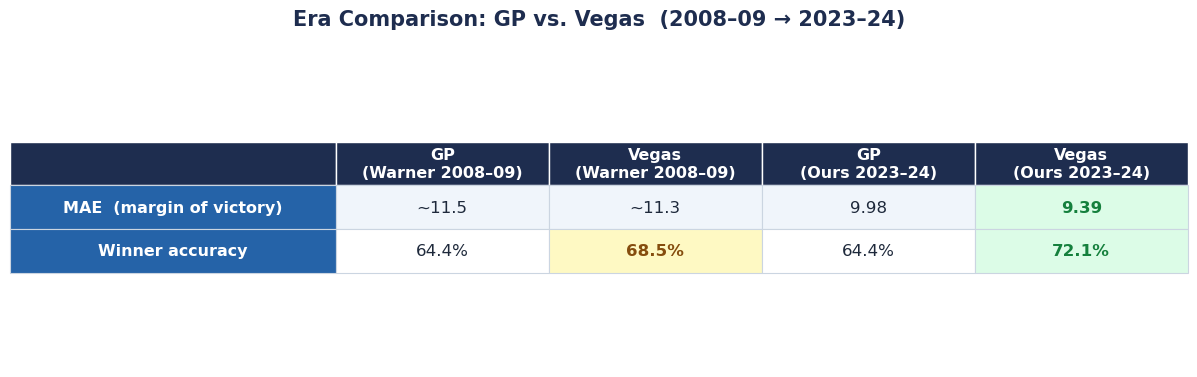

Saved → slide11_era_comparison.png


In [11]:
# ── Slide 11: Era Comparison — The Main Finding ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3.8))
fig.patch.set_facecolor(WHITE)

col_headers = [
    "GP\n(Warner 2008–09)",
    "Vegas\n(Warner 2008–09)",
    "GP\n(Ours 2023–24)",
    "Vegas\n(Ours 2023–24)",
]
row_labels = ["MAE  (margin of victory)", "Winner accuracy"]
data = [
    ["~11.5",  "~11.3",  "9.98",   "9.39" ],
    ["64.4%",  "68.5%",  "64.4%",  "72.1%"],
]

# green  = biggest/best number worth calling out
# yellow = comparison baseline
highlight = {
    (0, 3): "green",   # Vegas 2023-24 MAE   — market's best
    (1, 3): "green",   # Vegas 2023-24 acc   — market's best
    (1, 1): "yellow",  # Vegas Warner acc    — where Vegas started
}

draw_table(ax,
           title="Era Comparison: GP vs. Vegas  (2008–09 → 2023–24)",
           col_headers=col_headers,
           row_labels=row_labels,
           data=data,
           col_widths=[2.6, 1.7, 1.7, 1.7, 1.7],
           highlight=highlight,
           fontsize=12)

plt.tight_layout(pad=0.8)
plt.savefig("slide11_era_comparison.png", dpi=180, bbox_inches="tight", facecolor=WHITE)
plt.show()
print("Saved → slide11_era_comparison.png")

In [ ]:
# ── Slide 12: Feature Selection Results ──────────────────────────────────────
fig = plt.figure(figsize=(13, 7.5))
fig.patch.set_facecolor(WHITE)

# ── Top panel: accuracy / MAE comparison ─────────────────────────────────────
ax_top = fig.add_axes([0.03, 0.52, 0.94, 0.40])

col_headers = [
    "Warner 4-Feature GP\n(2023–24 test)",
    "Our 8-Feature GP\n(2023–24 test)",
    "Vegas\n(2023–24 test)",
]
row_labels = ["MAE  (margin of victory)", "Winner accuracy"]
data = [
    ["9.98",   "10.02",  "9.39" ],
    ["64.4%",  "67.1%",  "72.1%"],
]
highlight = {
    (1, 1): "green",   # our GP winner acc — improvement over Warner
    (0, 2): "green",   # Vegas MAE — best
    (1, 2): "yellow",  # Vegas winner acc — ultimate target
}

draw_table(ax_top,
           title="Feature Selection: Warner 4 Features vs. Our 8-Feature Set",
           col_headers=col_headers,
           row_labels=row_labels,
           data=data,
           col_widths=[2.5, 2.0, 2.0, 1.6],
           highlight=highlight,
           fontsize=12)

# ── Bottom panel: selected feature list ──────────────────────────────────────
ax_bot = fig.add_axes([0.03, 0.01, 0.94, 0.44])
ax_bot.axis("off")

ax_bot.text(0.5, 0.97, "Our 8 Selected Features  (forward search on 2015–2022 train data)",
            ha="center", va="top", fontsize=13, fontweight="bold", color=NAVY,
            transform=ax_bot.transAxes)

features = [
    ("H_win_pct",               "Home win %  (season avg)"),
    ("A_win_pct",               "Away win %  (season avg)"),
    ("A_points_scored_avg",     "Away points scored  (season avg)"),
    ("H_computed_strength",     "Home Keener (eigenvalue) strength"),
    ("A_total_yards_avg",       "Away total yards  (season avg)"),
    ("A_total_yards_streak",    "Away total yards  (4-game streak)"),
    ("H_points_allowed_streak", "Home points allowed  (4-game streak)"),
    ("A_turnovers_lost_avg",    "Away turnovers lost  (season avg)"),
]

# Two columns of 4 features each
col_x = [0.08, 0.55]
labels_left  = features[:4]
labels_right = features[4:]

for col_idx, col_feats in enumerate([ labels_left, labels_right ]):
    for row_idx, (feat_id, feat_desc) in enumerate(col_feats):
        y = 0.78 - row_idx * 0.185
        x = col_x[col_idx]
        # Bullet
        ax_bot.add_patch(plt.Rectangle((x - 0.012, y - 0.025), 0.018, 0.055,
                                        color=BLU_HDR, transform=ax_bot.transAxes, clip_on=False))
        ax_bot.text(x + 0.012, y + 0.005, feat_desc,
                    ha="left", va="center", fontsize=11, color=TXT,
                    transform=ax_bot.transAxes)
        ax_bot.text(x + 0.012, y - 0.065, feat_id,
                    ha="left", va="center", fontsize=9, color="#6b7280",
                    fontstyle="italic", transform=ax_bot.transAxes)

# Away team note
ax_bot.text(0.5, 0.02,
            "5 of 8 features are away-team stats — away performance is more predictive in modern data",
            ha="center", va="bottom", fontsize=10.5, color="#6b7280", style="italic",
            transform=ax_bot.transAxes)

plt.savefig("slide12_feature_selection.png", dpi=180, bbox_inches="tight", facecolor=WHITE)
plt.show()
print("Saved → slide12_feature_selection.png")

In [29]:
print(f"Warner 4-feature GP — median σ: {test_gp['gp_std'].median():.2f} pts")
print(f"Our 8-feature GP    — median σ: {test_sel['gp_std'].median():.2f} pts")

Warner 4-feature GP — median σ: 13.45 pts
Our 8-feature GP    — median σ: 13.24 pts


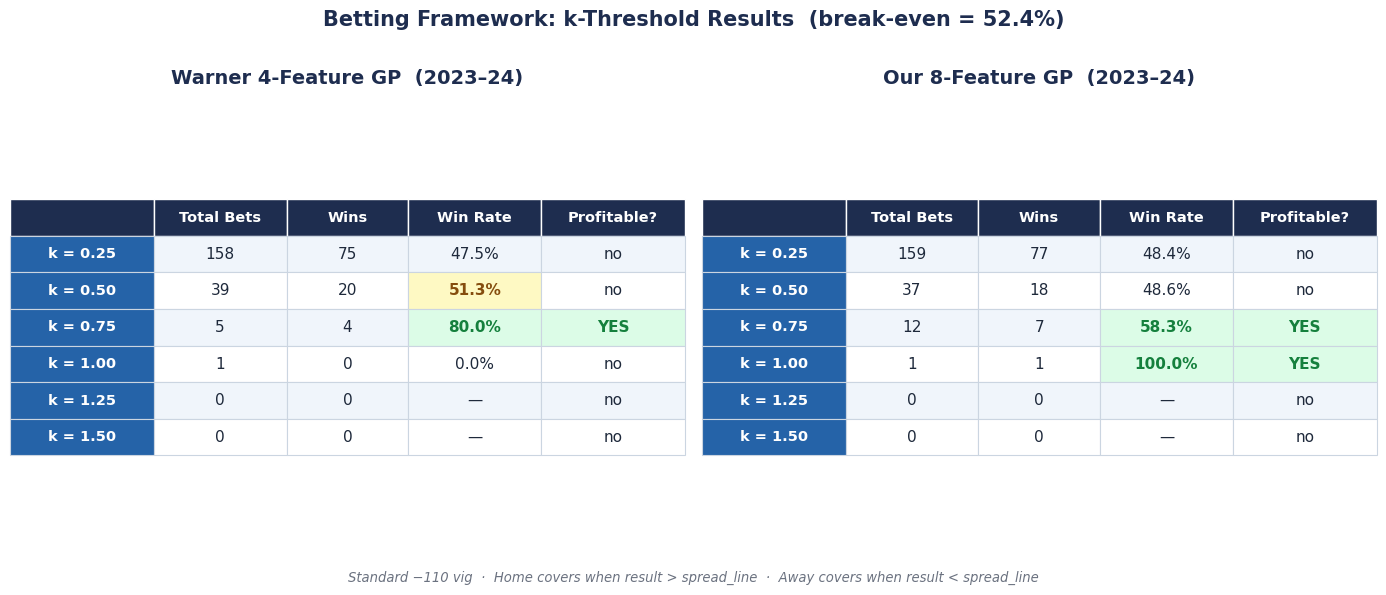

Saved → slide13_betting_framework.png


In [28]:
# ── Slide 13: Betting Framework ───────────────────────────────────────────────
# Uses test_gp (Warner 4-feature) and test_sel (our 8-feature) from earlier cells.
BREAKEVEN = 0.524   # standard -110 vig


def betting_rows(test_df, k_vals=(0.25, 0.5, 0.75, 1.0, 1.25, 1.5)):
    rows = []
    for k in k_vals:
        home = test_df[test_df["gp_pred"] - k * test_df["gp_std"] > test_df["spread_line"]]
        away = test_df[test_df["gp_pred"] + k * test_df["gp_std"] < test_df["spread_line"]]
        n    = len(home) + len(away)
        wins = int((home["result"] > home["spread_line"]).sum() +
                   (away["result"] < away["spread_line"]).sum())
        rate = wins / n if n > 0 else float("nan")
        rows.append([str(n), str(wins),
                     f"{rate:.1%}" if n > 0 else "—",
                     "YES" if rate > BREAKEVEN else "no"])
    return rows


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(WHITE)
fig.suptitle("Betting Framework: k-Threshold Results  (break-even = 52.4%)",
             fontsize=15, fontweight="bold", color=NAVY, y=1.01)

k_vals = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]

for ax, (label, test_df) in zip(axes, [
    ("Warner 4-Feature GP  (2023–24)", test_gp),
    ("Our 8-Feature GP  (2023–24)",    test_sel),
]):
    rows = betting_rows(test_df, k_vals)

    # Build highlight map: green = profitable, yellow = marginal (within 2 pp of breakeven)
    hl = {}
    for i, row in enumerate(rows):
        rate_str = row[2]   # win rate is now index 2 (no leading k column)
        if rate_str == "—":
            continue
        rate = float(rate_str.strip("%")) / 100
        n    = int(row[0])
        if n == 0:
            continue
        if rate > BREAKEVEN:
            hl[(i, 2)] = "green"   # win-rate cell
            hl[(i, 3)] = "green"   # profitable cell
        elif rate >= BREAKEVEN - 0.02:
            hl[(i, 2)] = "yellow"

    draw_table(ax,
               title=label,
               col_headers=["Total Bets", "Wins", "Win Rate", "Profitable?"],
               row_labels=[f"k = {k:.2f}" for k in k_vals],
               data=rows,
               col_widths=[1.3, 1.2, 1.1, 1.2, 1.3],
               highlight=hl,
               fontsize=11,
               row_scale=2.1)

# Footnote
fig.text(0.5, -0.03,
         "Standard −110 vig  ·  Home covers when result > spread_line  ·  Away covers when result < spread_line",
         ha="center", fontsize=9.5, color="#6b7280", style="italic")

plt.tight_layout(pad=1.2)
plt.savefig("slide13_betting_framework.png", dpi=180, bbox_inches="tight", facecolor=WHITE)
plt.show()
print("Saved → slide13_betting_framework.png")

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import numpy as np

SELECTED_FEATURES = [
    'H_win_pct', 'A_win_pct', 'A_points_scored_avg', 'H_computed_strength',
    'A_total_yards_streak', 'H_points_allowed_streak', 'A_total_yards_avg', 'A_turnovers_lost_avg'
]

train_rf = matchups[matchups["season"].isin(TRAIN_SEASONS)].dropna(subset=SELECTED_FEATURES + ["result"])
test_rf  = matchups[matchups["season"].isin(TEST_SEASONS)].dropna(subset=SELECTED_FEATURES + ["result", "spread_line"])

sc_rf    = StandardScaler()
X_tr_rf  = sc_rf.fit_transform(train_rf[SELECTED_FEATURES])
X_te_rf  = sc_rf.transform(test_rf[SELECTED_FEATURES])

rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, random_state=42)
rf.fit(X_tr_rf, train_rf["result"].values)

# std across trees = natural uncertainty estimate
tree_preds  = np.array([t.predict(X_te_rf) for t in rf.estimators_])
y_pred_rf   = tree_preds.mean(axis=0)
y_std_rf    = tree_preds.std(axis=0)

test_rf = test_rf.copy()
test_rf["gp_pred"] = y_pred_rf   # column names match betting function
test_rf["gp_std"]  = y_std_rf

mae_rf = mean_absolute_error(test_rf["result"], y_pred_rf)
acc_rf = (np.sign(y_pred_rf) == np.sign(test_rf["result"])).mean()

print(f"Random Forest  — MAE: {mae_rf:.2f}  |  Winner accuracy: {acc_rf:.1%}  |  Median σ: {np.median(y_std_rf):.2f} pts")
print(f"GP (8-feature) — MAE: {mae_sel:.2f}  |  Winner accuracy: {(np.sign(test_sel['gp_pred']) == np.sign(test_sel['result'])).mean():.1%}  |  Median σ: {test_sel['gp_std'].median():.2f} pts")
print(f"Vegas          — MAE: {mean_absolute_error(test_rf['result'], test_rf['spread_line']):.2f}  |  Winner accuracy: {(np.sign(test_rf['spread_line']) == np.sign(test_rf['result'])).mean():.1%}")


Random Forest  — MAE: 10.12  |  Winner accuracy: 64.9%  |  Median σ: 9.59 pts
GP (8-feature) — MAE: 10.02  |  Winner accuracy: 67.1%  |  Median σ: 13.24 pts
Vegas          — MAE: 9.39  |  Winner accuracy: 72.1%


In [31]:
BREAKEVEN = 0.524
k_vals = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]

print(f"{'k':<8} {'GP Bets':>8} {'GP WR':>8} {'RF Bets':>8} {'RF WR':>8}")
print("-" * 44)
for k in k_vals:
    gp_r = betting_rows(test_sel, [k])[0]
    rf_r = betting_rows(test_rf,  [k])[0]
    print(f"{k:<8.2f} {gp_r[0]:>8} {gp_r[2]:>8} {rf_r[0]:>8} {rf_r[2]:>8}")


k         GP Bets    GP WR  RF Bets    RF WR
--------------------------------------------
0.25          159    48.4%      264    51.1%
0.50           37    48.6%      135    48.1%
0.75           12    58.3%       49    51.0%
1.00            1   100.0%       20    50.0%
1.25            0        —        6    50.0%
1.50            0        —        3    66.7%


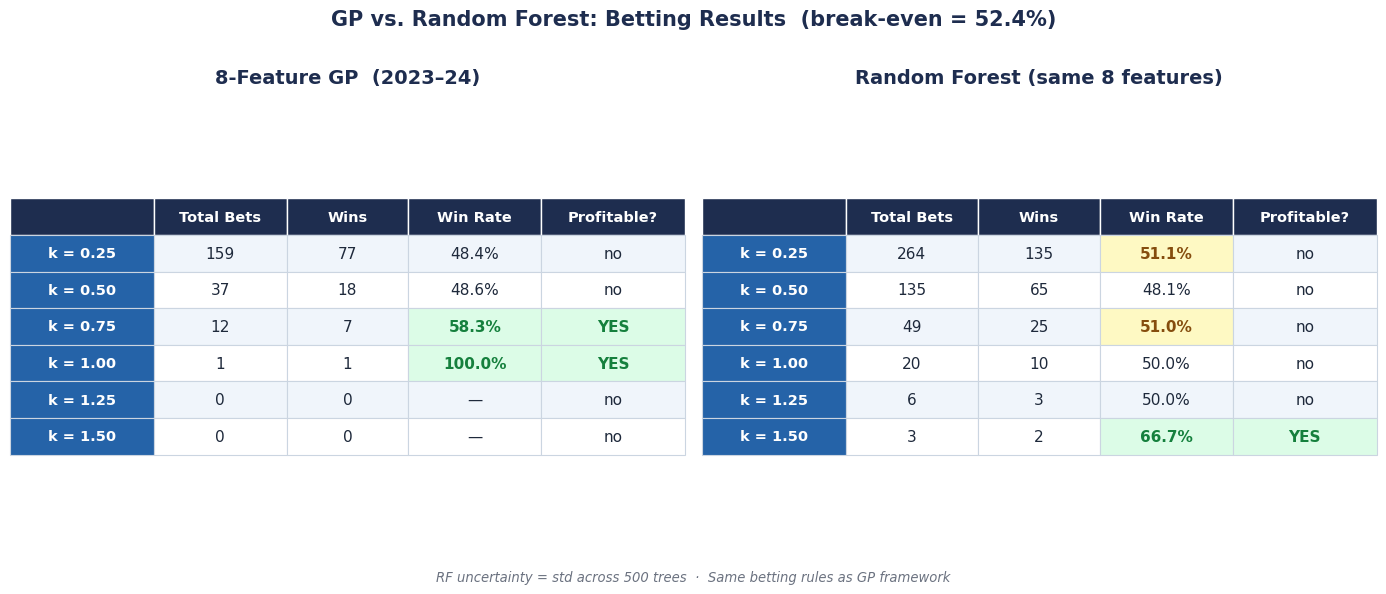

In [32]:
import matplotlib.pyplot as plt

NAVY="1e2d4f"; BLU_HDR="#2563a8"; ALT_ROW="#f0f5fb"; MAIN_ROW="#ffffff"
GRN_BG="#dcfce7"; GRN_TXT="#15803d"; YLW_BG="#fef9c3"; YLW_TXT="#854d0e"
BORDER="#cbd5e1"; WHITE="#ffffff"; TXT="#1e293b"
NAVY="#1e2d4f"

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(WHITE)
fig.suptitle("GP vs. Random Forest: Betting Results  (break-even = 52.4%)",
             fontsize=15, fontweight="bold", color=NAVY, y=1.01)

for ax, (label, test_df) in zip(axes, [
    ("8-Feature GP  (2023–24)",            test_sel),
    ("Random Forest (same 8 features)",    test_rf),
]):
    rows = betting_rows(test_df, k_vals)
    hl = {}
    for i, row in enumerate(rows):
        if row[2] == "—": continue
        rate = float(row[2].strip("%")) / 100
        if int(row[0]) == 0: continue
        if rate > BREAKEVEN:
            hl[(i, 2)] = "green"; hl[(i, 3)] = "green"
        elif rate >= BREAKEVEN - 0.02:
            hl[(i, 2)] = "yellow"

    draw_table(ax,
               title=label,
               col_headers=["Total Bets", "Wins", "Win Rate", "Profitable?"],
               row_labels=[f"k = {k:.2f}" for k in k_vals],
               data=rows,
               col_widths=[1.3, 1.2, 1.1, 1.2, 1.3],
               highlight=hl,
               fontsize=11,
               row_scale=2.1)

fig.text(0.5, -0.03,
         "RF uncertainty = std across 500 trees  ·  Same betting rules as GP framework",
         ha="center", fontsize=9.5, color="#6b7280", style="italic")

plt.tight_layout(pad=1.2)
plt.savefig("slide_gp_vs_rf_betting.png", dpi=180, bbox_inches="tight", facecolor=WHITE)
plt.show()
